# Análise de Vendas Consolidadas — Relatório de Profiling

Este notebook consome os dados já higienizados e persistidos pelo pipeline de ingestão (`src/ingestion_pipeline.py`) na tabela `tb_vendas_consolidada` do banco `varejo.db`, e gera:

1. Uma exportação de intercâmbio em JSON apenas com as vendas de E-commerce;
2. Estatísticas descritivas de faturamento;
3. Um histograma da distribuição de faturamento por transação.

> **Pré-requisito:** execute antes `python src/ingestion_pipeline.py` a partir da raiz do repositório, para que o arquivo `varejo.db` exista e esteja atualizado.

In [1]:
import json
import os
import sqlite3

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Caminhos relativos à raiz do repositório (notebook roda a partir de /notebooks)
BASE_DIR = os.path.dirname(os.getcwd())
DB_PATH = os.path.join(BASE_DIR, "varejo.db")
OUTPUT_JSON = os.path.join(BASE_DIR, "data", "vendas_ecommerce_limpo.json")
OUTPUT_PNG = os.path.join(BASE_DIR, "histograma_vendas.png")

conn = sqlite3.connect(DB_PATH)
print("Conexão com o banco de dados estabelecida em:", DB_PATH)

Conexão com o banco de dados estabelecida em: /home/claude/tp1/varejo.db


## 1. Exportação de Intercâmbio — Vendas de E-commerce

Consulta SQL que filtra apenas as transações originadas no canal **E-commerce** já gravadas no banco, e exportação do resultado para `data/vendas_ecommerce_limpo.json`.

In [2]:
query_ecommerce = """
    SELECT id_transacao, data_venda, id_produto, quantidade, valor_unitario, canal_venda
    FROM tb_vendas_consolidada
    WHERE canal_venda = 'E-commerce'
"""

df_ecommerce = pd.read_sql(query_ecommerce, conn)

registros = df_ecommerce.to_dict(orient="records")
with open(OUTPUT_JSON, "w", encoding="utf-8") as f:
    json.dump(registros, f, ensure_ascii=False, indent=2)

print(f"{len(df_ecommerce)} transações de E-commerce exportadas para: {OUTPUT_JSON}")
df_ecommerce

6 transações de E-commerce exportadas para: /home/claude/tp1/data/vendas_ecommerce_limpo.json


## 2. Estatística Descritiva de Faturamento

Faturamento total, preço unitário médio e faturamento segmentado por canal de venda, considerando toda a base consolidada (E-commerce + Lojas Físicas).

In [3]:
df_vendas = pd.read_sql("SELECT * FROM tb_vendas_consolidada", conn)
df_vendas["faturamento"] = df_vendas["quantidade"] * df_vendas["valor_unitario"]

faturamento_total = df_vendas["faturamento"].sum()
preco_medio = df_vendas["valor_unitario"].mean()
faturamento_por_canal = df_vendas.groupby("canal_venda")["faturamento"].sum()

print(f"Faturamento total: R$ {faturamento_total:,.2f}")
print(f"Preço unitário médio: R$ {preco_medio:,.2f}")
print("\nFaturamento por canal de venda:")
print(faturamento_por_canal.to_string())

Faturamento total: R$ 3,065.70
Preço unitário médio: R$ 78.55

Faturamento por canal de venda:
canal_venda
E-commerce     1189.7
Loja Física    1876.0


## 3. Análise Gráfica Univariada — Distribuição de Faturamento por Transação

Histograma estilizado (Seaborn) da distribuição de faturamento (`quantidade × valor_unitario`) por transação, salvo em `histograma_vendas.png`.

Histograma salvo em: /home/claude/tp1/histograma_vendas.png


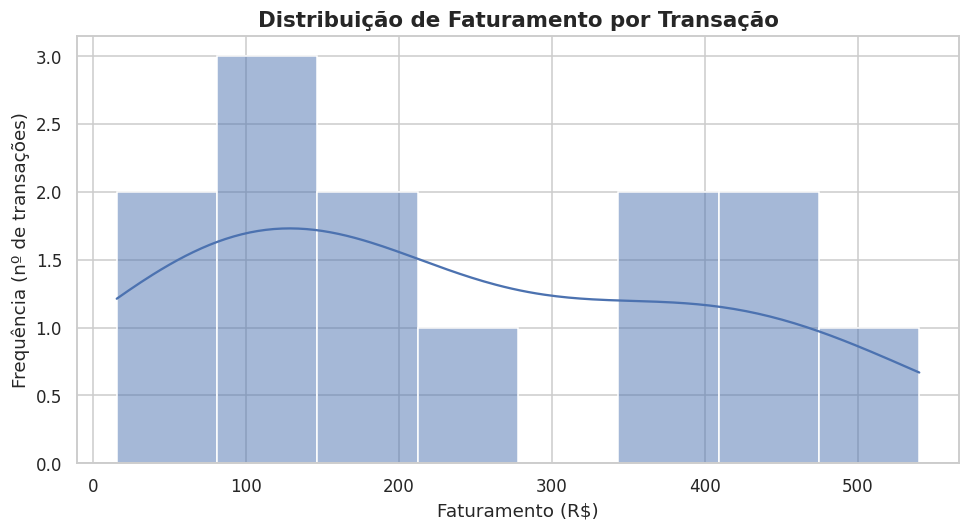

In [4]:
sns.set_theme(style="whitegrid")

plt.figure(figsize=(9, 5))
ax = sns.histplot(df_vendas["faturamento"], bins=8, kde=True, color="#4C72B0", edgecolor="white")
ax.set_title("Distribuição de Faturamento por Transação", fontsize=14, fontweight="bold")
ax.set_xlabel("Faturamento (R$)")
ax.set_ylabel("Frequência (nº de transações)")
plt.tight_layout()
plt.savefig(OUTPUT_PNG, dpi=150, bbox_inches="tight")
plt.show()

print(f"Histograma salvo em: {OUTPUT_PNG}")

In [5]:
conn.close()